<a href="https://colab.research.google.com/github/christi-fred/DeepLearning_Project/blob/main/project_2_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Model compression - Pruning

# CIFAR Dataset Import and Set up

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch. utils.data import DataLoader
from torch import nn

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch version:", torch.__version__)

Device: cuda
Torch version: 2.10.0+cu128


CIFAR-10 dataset

Downloads CIFAR-10 automatically into ./data

Creates:

train_set (50,000 images)

test_set (10,000 images)

Converts each image to a tensor using ToTensor()

Important: ToTensor() converts images from:

pixel range 0–255 → float range 0–1

shape becomes (C, H, W) = (3, 32, 32)

In [3]:
# NO normalization, NO augmentation.
# Loading raw images first.
basic_transform = transforms.ToTensor()

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=basic_transform
)

test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=basic_transform
)

print("Train size:", len(train_set))
print("Test size:", len(test_set))
print("Class names:", train_set.classes)

100%|██████████| 170M/170M [00:02<00:00, 71.5MB/s]


Train size: 50000
Test size: 10000
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


ONE data sample
x is the image tensor

y is the label (0–9)

x.shape = (3, 32, 32) means:

3 channels (RGB)

32x32 pixels

In [4]:
x, y = train_set[0]  # first training example

print("x type:", type(x))
print("x shape:", x.shape)          # should be torch.Size([3, 32, 32])
print("x dtype:", x.dtype)          # float32
print("x min/max:", x.min().item(), x.max().item())

print("y:", y)
print("y class name:", train_set.classes[y])

x type: <class 'torch.Tensor'>
x shape: torch.Size([3, 32, 32])
x dtype: torch.float32
x min/max: 0.0 1.0
y: 6
y class name: frog


Display the image - visualize what CIFAR-10 looks like

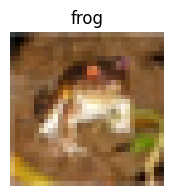

In [5]:
def show_image(img_tensor, label):
    # img_tensor: (3, 32, 32)
    img = img_tensor.permute(1, 2, 0)  # (H, W, C) for matplotlib
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    plt.title(train_set.classes[label])
    plt.axis("off")
    plt.show()

show_image(x, y)

Show a grid of multiple images---
CIFAR-10 is small images (32×32)---
Some classes look similar (cat vs dog), which is why it’s challenging

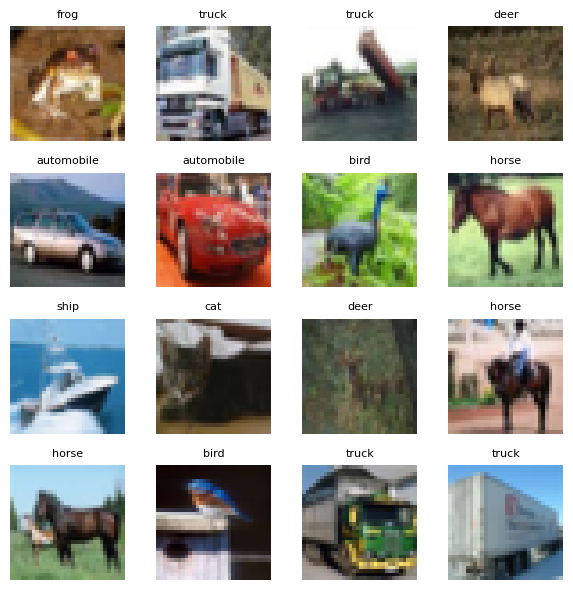

In [6]:
def show_batch(dataset, n=16):
    plt.figure(figsize=(6,6))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)
        plt.subplot(4, 4, i+1)
        plt.imshow(img)
        plt.title(train_set.classes[label], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_set, n=16)

*DataLoader*

Instead of feeding 1 image at a time, training uses batches

xb.shape = (128, 3, 32, 32) means 128 images at once

In [7]:
batch_size = 128

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch image shape:", xb.shape)  # (batch_size, 3, 32, 32)
print("Batch label shape:", yb.shape)  # (batch_size,)
print("First 10 labels:", yb[:10].tolist())

Batch image shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])
First 10 labels: [2, 9, 0, 2, 3, 1, 9, 3, 9, 3]


check class balance

In [8]:
from collections import Counter

labels = [train_set[i][1] for i in range(len(train_set))]
counts = Counter(labels)

for k in range(10):
    print(train_set.classes[k], ":", counts[k])

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


Flatten the image (turn 3×32×32 into 3072 numbers)

A fully connected network expects a 2D input: (batch, features)

CIFAR image (3,32,32) → 3*32*32 = 3072 features

Now you have (B, 3072)

In [9]:
# --------------------------------------------------
# Flatten Dataset
# --------------------------------------------------

xb, yb = next(iter(train_loader))  # xb: (B, 3, 32, 32)

print("Before flatten:", xb.shape)

xb_flat = xb.view(xb.shape[0], -1)  # (B, 3072)

print("After flatten:", xb_flat.shape)
print("One image becomes length:", xb_flat.shape[1])

Before flatten: torch.Size([128, 3, 32, 32])
After flatten: torch.Size([128, 3072])
One image becomes length: 3072


In [10]:
# -------------------------------------------------------------------------------
# Dataset and DataLoaders for CNN Experiments with normalization and augmentation.
# -------------------------------------------------------------------------------
cnn_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

cnn_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

cnn_train_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=cnn_train_transform
)

cnn_test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=cnn_test_transform
)

cnn_train_loader = DataLoader(
    cnn_train_set,
    batch_size=128,
    shuffle=True,
    num_workers=0, # Changed from 2 to 0 to prevent multiprocessing error
    pin_memory=True
)

cnn_test_loader = DataLoader(
    cnn_test_set,
    batch_size=128,
    shuffle=False,
    num_workers=0, # Changed from 2 to 0 to prevent multiprocessing error
    pin_memory=True
)

print("CNN train size:", len(cnn_train_set))
print("CNN test size:", len(cnn_test_set))

CNN train size: 50000
CNN test size: 10000


# Model Compression Implementation Steps

Use Pytorch built in functions instead of CUSTOM CODE to use Original CNN architecture from Project 1

In [29]:
# This model keeps the SAME architecture as Project 1,
# but uses PyTorch built-in layers instead of manual
# Conv2D / Linear classes.
#

# Revised Project 1 architecture:
#   Conv(3 -> 32) -> ReLU -> MaxPool
#   Conv(32 -> 64) -> ReLU -> MaxPool
#   Conv(64 -> 128) -> ReLU -> MaxPool
#   Flatten
#   FC(128*3*3 -> 256) -> ReLU
#   FC(256 -> 10)
#
# CIFAR-10 input image size = 3 x 32 x 32
# --------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_Project_3(nn.Module):
    def __init__(self):
        super().__init__()

        # --------------------------------------------------
        # First convolution layer
        #
        # Input:  3 x 32 x 32
        # Output: 32 x 32 x 32
        #
        # Why?
        # - in_channels=3 because CIFAR-10 images are RGB
        # - out_channels=32 matches Project 1 model
        # - kernel_size=3 matches Project 1 model
        # - padding=1 keeps width/height the same
        # --------------------------------------------------
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # --------------------------------------------------
        # Second convolution layer
        #
        # Input:  32 x 16 x 16  (after first pool)
        # Output: 64 x 16 x 16
        #
        # This matches Project 1 model:
        # Conv(32 -> 64)
        # --------------------------------------------------
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # --------------------------------------------------
        # Third convolution layer
        #
        # Input:  64 x 16 x 16  (after first pool)
        # Output: 64 x 16 x 16
        #
        # This matches Project 1 model:
        # Conv(32 -> 64)
        # --------------------------------------------------
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )
        # Max Pooling layer
        #
        # kernel_size=2, stride=2
        #
        # This reduces spatial size by half:
        # 32x32 -> 16x16
        # 16x16 -> 8x8
        #
        # This replaces Project 1 AvgPool2D(2,2)
        # --------------------------------------------------
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --------------------------------------------------
        # First fully connected layer
        #
        # After 2 pooling layers:
        # Input image: 32x32
        # After pool1: 16x16
        # After pool2: 8x8
        #
        # Number of channels after conv2 = 64
        # So flattened size = 64 * 8 * 8
        #
        # This matches Project 1:
        # Linear(64 * 8 * 8, 256)
        # --------------------------------------------------
        self.fc1 = nn.Linear(128 * 4 * 4, 256) # Changed from 128 * 3 * 3

        # --------------------------------------------------
        # Final output layer
        #
        # Input: 256 hidden units
        # Output: 10 classes for CIFAR-10
        #
        # This matches Project 1:
        # Linear(256, 10)
        # --------------------------------------------------
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # --------------------------------------------------
        # Input x shape:
        # (batch_size, 3, 32, 32)
        # --------------------------------------------------

        # First block:
        # Conv -> ReLU -> MaxPool
        #
        # Shape change:
        # (N, 3, 32, 32)
        # -> (N, 32, 32, 32) after conv1
        # -> (N, 32, 32, 32) after ReLU
        # -> (N, 32, 16, 16) after pool
        x = self.pool(F.relu(self.conv1(x)))

        # Second block:
        # Conv -> ReLU -> MaxPool
        #
        # Shape change:
        # (N, 32, 16, 16)
        # -> (N, 64, 16, 16) after conv2
        # -> (N, 64, 16, 16) after ReLU
        # -> (N, 64, 8, 8) after pool
        x = self.pool(F.relu(self.conv2(x)))

        # Third block:
        # Conv -> ReLU -> MaxPool
        #
        # Shape change:
        # (N, 64, 8, 8)
        # -> (N, 128, 8, 8) after conv3
        # -> (N, 128, 8, 8) after ReLU
        # -> (N, 128, 4, 4) after pool
        x = self.pool(F.relu(self.conv3(x)))

        # --------------------------------------------------
        # Flatten tensor for fully connected layer
        #
        # Before flatten:
        #   (N, 128, 4, 4)
        #
        # After flatten:
        #   (N, 128*4*4)
        # --------------------------------------------------
        x = x.view(x.size(0), -1)

        # First fully connected layer + ReLU
        #
        # Shape:
        # (N, 128*4*4) -> (N, 256)
        x = F.relu(self.fc1(x))

        # Final classification layer
        #
        # Shape:
        # (N, 256) -> (N, 10)
        #
        # Output = raw logits
        # Didn't apply softmax here because
        # CrossEntropyLoss in PyTorch expects logits
        x = self.fc2(x)

        return x

Evaluation function

In [25]:
# --------------------------------------------------
# Model Evaluation Function
# --------------------------------------------------

@torch.no_grad()   # disables gradient calculation (faster + saves memory)
def evaluate_model(model, loader, device="cpu"):

    # Set model to evaluation mode
    model.eval()

    correct = 0   # number of correct predictions
    total = 0     # total number of samples

    # Loop through dataset
    for xb, yb in loader:

        # Move data to CPU or GPU
        xb = xb.to(device)
        yb = yb.to(device)

        # Forward pass (get model predictions)
        outputs = model(xb)

        # Get predicted class (index with highest score)
        preds = outputs.argmax(dim=1)

        # Count how many predictions are correct
        correct += (preds == yb).sum().item()

        # Count total samples
        total += yb.size(0)

    # Compute accuracy
    # Example: 0.75 means 75% accuracy
    accuracy = correct / total

    return accuracy

Train model function

In [16]:
# --------------------------------------------------
# Training Function for CNN (PyTorch version)
#
# This function trains the model using the training dataset
# and evaluates it on the test dataset after each epoch.
#
# Uses:
# - Adam optimizer
# - CrossEntropyLoss for classification
# --------------------------------------------------

def train_model(model, train_loader, test_loader, epochs=10, lr=0.001, device="cpu"):

    # Set model to training mode
    model.train()

    # Adam optimizer (same idea as Project 1, but using PyTorch built-in)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # CrossEntropyLoss automatically applies softmax + log
    # so we pass raw logits from the model
    criterion = nn.CrossEntropyLoss()

    # Lists to store training history (for plots later)
    train_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []

    # --------------------------------------------------
    # Loop over epochs
    # --------------------------------------------------
    for epoch in range(1, epochs + 1):

        model.train()   # ensure model is in training mode

        running_loss = 0.0   # total loss for the epoch
        correct = 0          # number of correct predictions
        total = 0            # total samples

        # --------------------------------------------------
        # Loop over mini-batches
        # --------------------------------------------------
        for xb, yb in train_loader:

            # Move data to CPU or GPU
            xb = xb.to(device)
            yb = yb.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass (get predictions)
            outputs = model(xb)

            # Compute loss
            loss = criterion(outputs, yb)

            # Backward pass (compute gradients)
            loss.backward()

            # Update model weights
            optimizer.step()

            # Accumulate loss
            running_loss += loss.item()

            # Compute accuracy for this batch
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        # --------------------------------------------------
        # Compute epoch-level metrics
        # --------------------------------------------------
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Evaluate on test set (no training)
        test_acc = evaluate_model(model, test_loader, device=device)

        # Save history for later analysis/plots
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        test_acc_hist.append(test_acc)

        # Print progress
        print(
            f"Epoch {epoch}: "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc*100:.2f}% "
            f"test_acc={test_acc*100:.2f}%"
        )

    # Return training history
    return train_loss_hist, train_acc_hist, test_acc_hist

**Pruning function**

In [17]:
import torch.nn.utils.prune as prune

# --------------------------------------------------
# Apply Pruning to Model
#
# This function removes a percentage of weights
# (based on magnitude) from Conv and Linear layers.
# --------------------------------------------------

def apply_pruning(model, amount=0.3):
    # Loop through all layers in the model
    for module in model.modules():

        # Apply pruning only to Conv and Linear layers
        if isinstance(module, (nn.Conv2d, nn.Linear)):

            # L1 unstructured pruning:
            # removes smallest magnitude weights
            prune.l1_unstructured(
                module,
                name="weight",
                amount=amount   # percentage of weights to remove
            )

**Remove Prunning mask**

In [18]:
# --------------------------------------------------
# Finalize Pruning
#
# This function makes pruning permanent by removing
# the pruning mask and keeping only the pruned weights.
# --------------------------------------------------

def finalize_pruning(model):

    # Loop through all layers in the model
    for module in model.modules():

        # Apply only to Conv and Linear layers
        if isinstance(module, (nn.Conv2d, nn.Linear)):

            # Check if pruning was applied to this layer
            if hasattr(module, "weight_orig"):

                # Remove pruning reparameterization
                # and keep the pruned weights permanently
                prune.remove(module, "weight")

**parameter counting fuction**

In [19]:
# --------------------------------------------------
# Count Total Parameters
#
# This function returns the total number of parameters
# in the model (including both zero and non-zero values).
# --------------------------------------------------

def count_total_params(model):

    # p.numel() gives total number of elements in each tensor
    # sum over all parameters in the model
    return sum(p.numel() for p in model.parameters())

**nonzero remaining parameters after pruning**

In [20]:
# --------------------------------------------------
# Count Non-Zero Parameters
#
# This function counts how many parameters are still
# non-zero after pruning.
#
# This represents the "remaining parameters" in the model.
# --------------------------------------------------

# def count_nonzero_params(model):

#     total_nonzero = 0  # initialize counter

#     # Loop through all parameters in the model
#     for param in model.parameters():

#         # Count number of non-zero values in this tensor
#         total_nonzero += torch.count_nonzero(param).item()

#     return total_nonzero

def count_nonzero_params(model):
    total_nonzero = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            # Count non-zero weights after pruning mask
            total_nonzero += torch.count_nonzero(module.weight).item()

            # Count bias values if bias exists
            if module.bias is not None:
                total_nonzero += torch.count_nonzero(module.bias).item()

    return total_nonzero

**Functions for measuring memory and computation evaluation metrics**

In [21]:
print('Installing torchprofile...')
!pip install torchprofile 1>/dev/null
print('All required packages have been successfully installed!')

Installing torchprofile...
All required packages have been successfully installed!


In [22]:
from torchprofile import profile_macs
def get_model_macs(model, inputs, count_nonzero_only=False) -> int:
    if isinstance(model, torch.nn.Module): # For standard PyTorch nn.Module models
        # profile_macs might still fail if the nn.Module contains custom operations
        return profile_macs(model, inputs)
    #elif isinstance(model, ManualCNN_opt_maxpool): # For your custom model
     #   return get_manual_model_macs(model, inputs, count_nonzero_only)
    else:
        raise TypeError(f"Unsupported model type: {type(model)}. Cannot calculate MACs.")

def get_sparsity(tensor: torch.Tensor) -> float:
    """
    calculate the sparsity of the given tensor
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    """
    return 1 - float(tensor.count_nonzero()) / tensor.numel()


def get_model_sparsity(model: nn.Module) -> float:
    """
    calculate the sparsity of the given model
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    """
    num_nonzeros, num_elements = 0, 0
    for param in model.parameters():
        num_nonzeros += param.count_nonzero()
        num_elements += param.numel()
    return 1 - float(num_nonzeros) / num_elements

def get_num_parameters(model, count_nonzero_only=False) -> int:
    """
    calculate the total number of parameters of model
    :param count_nonzero_only: only count nonzero weights
    """
    num_counted_elements = 0
    if hasattr(model, 'parameters'): # For torch.nn.Module models
        for param in model.parameters():
            if count_nonzero_only:
                num_counted_elements += param.count_nonzero()
            else:
                num_counted_elements += param.numel()
    elif hasattr(model, 'params'): # For custom models like ManualCNN_opt_maxpool
        for param, _ in model.params(): # model.params() returns (param, grad) tuples
            if count_nonzero_only:
                num_counted_elements += param.count_nonzero()
            else:
                num_counted_elements += param.numel()
    else:
        raise AttributeError("Model does not have 'parameters()' or 'params()' method.")
    return num_counted_elements


def get_model_size(model: nn.Module, data_width=32, count_nonzero_only=False) -> int:
    """
    calculate the model size in bits
    :param data_width: #bits per element
    :param count_nonzero_only: only count nonzero weights
    """
    return get_num_parameters(model, count_nonzero_only) * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

# Train Baseline Model

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --------------------------------------------------
# Train Baseline Model (Before Pruning) for 5 epochs
#
# This is the original CNN without any compression.
# This as a reference to compare with pruned models.
# --------------------------------------------------

# Initialize 3 layer CNN Baseline model and move to device (CPU/GPU)
baselinelayer_3_model = CNN_Project_3().to(device)

# Train the model
baseline_3_loss, baseline_3_train_acc, baseline_3_test_acc = train_model(
    baselinelayer_3_model,
    cnn_train_loader,
    cnn_test_loader,
    epochs=5,
    lr=0.001,
    device=device
)

# --------------------------------------------------
# Print baseline metrics
# --------------------------------------------------


# Total parameters in the model
dense_params = count_total_params(baselinelayer_3_model)

# Non-zero parameters (should be same as total before pruning)
dense_non_zero_params = count_nonzero_params(baselinelayer_3_model)

# Model Size
dense_model_size = get_model_size(baselinelayer_3_model, count_nonzero_only=True)

# FLOPS
sample_input = torch.randn(1, 3, 32, 32).to(device) # Batch size 1, 3 channels, 32x32 resolution
dense_flops = get_model_macs(baselinelayer_3_model, sample_input, count_nonzero_only=True)

print(f"Baseline Model has {dense_params} parameters")
print(f"Baseline Model has {dense_non_zero_params} non zero parameters")
print(f"Actual Model Size={dense_model_size/MiB:.2f} MiB")
print(f"Actual Model Train Accuracy={baseline_3_train_acc[-1]*100:.2f}%")
print(f"Actual Model Test Accuracy={baseline_3_test_acc[-1]*100:.2f}%")
print(f"Baseline Model has {dense_flops / 1e6:.2f} M FLOPs (MACs).")

Epoch 1: train_loss=1.5961 train_acc=41.68% test_acc=54.67%
Epoch 2: train_loss=1.2360 train_acc=55.54% test_acc=61.25%
Epoch 3: train_loss=1.0552 train_acc=62.43% test_acc=68.06%
Epoch 4: train_loss=0.9355 train_acc=66.81% test_acc=69.78%
Epoch 5: train_loss=0.8548 train_acc=69.81% test_acc=72.03%
Baseline Model has 620362 parameters
Baseline Model has 620362 non zero parameters
Actual Model Size=2.37 MiB
Actual Model Train Accuracy=69.81%
Actual Model Test Accuracy=72.03%
Baseline Model has 10.85 M FLOPs (MACs).


Apply Pruning and Fine Tune

In [28]:
# --------------------------------------------------
# Apply Pruning to Trained Model
#
# This step removes a percentage of weights from the model
# and then fine-tunes it to recover performance.
# --------------------------------------------------


# Create a fresh model
prunedlayer_model = CNN_Project_3().to(device)

# Apply pruning (e.g., remove 30% of weights)
apply_pruning(prunedlayer_model, amount=0.3)

# Make pruning permanent (remove mask)
finalize_pruning(prunedlayer_model)

# --------------------------------------------------
# Print model size after pruning
# --------------------------------------------------

# Total parameters (same as before pruning)
print("After pruning total params:", count_total_params(prunedlayer_model))

# Remaining non-zero parameters (reduced after pruning)
print("After pruning nonzero params:", count_nonzero_params(prunedlayer_model))

# --------------------------------------------------
# Fine-tune the pruned model
#
# After pruning, accuracy usually drops, so we retrain
# for a few epochs with a smaller learning rate.
# --------------------------------------------------

pruned_loss, pruned_train_acc, pruned_test_acc = train_model(
    prunedlayer_model,
    cnn_train_loader,
    cnn_test_loader,
    epochs=5,
    # fewer epochs for fine-tuning
    lr = 0.001,
    device=device
)

# -------------------------------------------------------------------
# Print model evaluation memory and computation metrics after pruning
# -------------------------------------------------------------------

sparse_params = count_total_params(prunedlayer_model)
sparse_non_zero_params = count_nonzero_params(prunedlayer_model)
sparse_model_size = get_model_size(prunedlayer_model, count_nonzero_only=True)
sample_input = torch.randn(1, 3, 32, 32).to(device) # Batch size 1, 3 channels, 32x32 resolution
sparse_flops = get_model_macs(prunedlayer_model, sample_input, count_nonzero_only=True)
print(f"Sparse Model has {sparse_params} parameters")
print(f"Sparse Model has {sparse_non_zero_params} non zero parameters")
print(f"Sparse Model Size={sparse_model_size/MiB:.2f} MiB")
print(f"Sparse Model Train Accuracy={pruned_train_acc[-1]*100:.2f}%")
print(f"Sparse Model Test Accuracy={pruned_test_acc[-1]*100:.2f}%")
print(f"Sparse Model has {sparse_flops / 1e6:.2f} M FLOPs (MACs).")

After pruning total params: 620362
After pruning nonzero params: 434401
Epoch 1: train_loss=1.6197 train_acc=40.49% test_acc=53.34%
Epoch 2: train_loss=1.2576 train_acc=54.82% test_acc=61.59%
Epoch 3: train_loss=1.0788 train_acc=61.71% test_acc=67.69%
Epoch 4: train_loss=0.9542 train_acc=66.09% test_acc=69.16%
Epoch 5: train_loss=0.8671 train_acc=69.38% test_acc=72.92%
Sparse Model has 620362 parameters
Sparse Model has 611865 non zero parameters
Sparse Model Size=2.33 MiB
Sparse Model Train Accuracy=69.38%
Sparse Model Test Accuracy=72.92%
Sparse Model has 10.85 M FLOPs (MACs).


Pruning experiment

In [30]:
# Different pruning levels to test
pruning_levels = [0.1, 0.3, 0.5, 0.7]

# Store experiment results
results = []

for p in pruning_levels:
    print(f"\n--- Pruning amount: {p} ---")

    # Create a fresh model
    b_model = CNN_Project_3().to(device)

    # Train baseline model first
    #train_model(
      #  b_model,
       # cnn_train_loader,
       # cnn_test_loader,
       # epochs=5,
       # lr=0.001,
       # device=device
    #)

    # Save total params before pruning
    total_params = count_total_params(b_model)

    # Apply pruning
    apply_pruning(b_model, amount=p)

    # Count remaining non-zero params right after pruning
    remaining_params = count_nonzero_params(b_model)

    # Make pruning permanent
    finalize_pruning(b_model)

    # Fine-tune pruned model
    train_model(
        b_model,
        cnn_train_loader,
        cnn_test_loader,
        epochs=5,
        lr=0.001,
        device=device
    )

    # Evaluate final accuracy
    final_test_acc = evaluate_model(b_model, cnn_test_loader, device=device)

    # Save results
    results.append({
        "pruning_amount": p,
        "total_params": total_params,
        "remaining_params": remaining_params,
        "test_accuracy": final_test_acc
    })

    # Print summary
    print("Total params:", total_params)
    print("Remaining params:", remaining_params)
    print(f"Final test accuracy: {final_test_acc*100:.2f}%")


--- Pruning amount: 0.1 ---
Epoch 1: train_loss=1.6204 train_acc=40.17% test_acc=51.54%
Epoch 2: train_loss=1.2751 train_acc=53.58% test_acc=62.56%
Epoch 3: train_loss=1.0905 train_acc=61.09% test_acc=66.68%
Epoch 4: train_loss=0.9623 train_acc=65.80% test_acc=70.85%
Epoch 5: train_loss=0.8825 train_acc=68.89% test_acc=72.43%
Total params: 620362
Remaining params: 558375
Final test accuracy: 72.43%

--- Pruning amount: 0.3 ---
Epoch 1: train_loss=1.6142 train_acc=40.46% test_acc=53.27%
Epoch 2: train_loss=1.2479 train_acc=54.93% test_acc=62.44%
Epoch 3: train_loss=1.0593 train_acc=62.06% test_acc=67.97%
Epoch 4: train_loss=0.9436 train_acc=66.57% test_acc=70.14%
Epoch 5: train_loss=0.8536 train_acc=70.04% test_acc=72.89%
Total params: 620362
Remaining params: 434401
Final test accuracy: 72.89%

--- Pruning amount: 0.5 ---
Epoch 1: train_loss=1.6404 train_acc=39.79% test_acc=50.77%
Epoch 2: train_loss=1.2945 train_acc=53.00% test_acc=60.25%
Epoch 3: train_loss=1.1107 train_acc=60.35% t

# Ablation Study

Baseline Model Evaluated metrics: FLOPS, Test Accuracy, Training Accuracy

In [ ]:
dense_params = count_total_params(baselinelayer_3_model)
dense_non_zero_params = count_nonzero_params(baselinelayer_3_model)
dense_model_size = get_model_size(baselinelayer_3_model, count_nonzero_only=True)
sample_input = torch.randn(1, 3, 32, 32).to(device) # Batch size 1, 3 channels, 32x32 resolution
dense_flops = get_model_macs(baselinelayer_3_model, sample_input, count_nonzero_only=True)
print(f"Baseline Model has {dense_params} parameters")
print(f"Baseline Model has {dense_non_zero_params} non zero parameters")
print(f"Actual Model Size={dense_model_size/MiB:.2f} MiB")
print(f"Actual Model Train Accuracy={baseline_3_train_acc[-1]*100:.2f}%")
print(f"Actual Model Test Accuracy={baseline_3_test_acc[-1]*100:.2f}%")
print(f"Baseline Model has {dense_flops / 1e6:.2f} M FLOPs (MACs).")

Baseline Model has 620362 parameters
Baseline Model has 620362 non zero parameters
Actual Model Size=2.37 MiB
Actual Model Train Accuracy=61.42%
Actual Model Test Accuracy=64.45%
Baseline Model has 10.86 M FLOPs (MACs).


Pruned Model with 30% sparsity evaluation metrics

In [31]:
sparse_params = count_total_params(prunedlayer_model)
sparse_non_zero_params = count_nonzero_params(prunedlayer_model)
sparse_model_size = get_model_size(prunedlayer_model, count_nonzero_only=True)
sample_input = torch.randn(1, 3, 32, 32).to(device) # Batch size 1, 3 channels, 32x32 resolution
sparse_flops = get_model_macs(prunedlayer_model, sample_input, count_nonzero_only=True)
print(f"Sparse Model has {sparse_params} parameters")
print(f"Sparse Model has {sparse_non_zero_params} non zero parameters")
print(f"Sparse Model Size={sparse_model_size/MiB:.2f} MiB")
print(f"Sparse Model Train Accuracy={pruned_train_acc[-1]*100:.2f}%")
print(f"Sparse Model Test Accuracy={pruned_test_acc[-1]*100:.2f}%")
print(f"Sparse Model has {sparse_flops / 1e6:.2f} M FLOPs (MACs).")

Sparse Model has 620362 parameters
Sparse Model has 611865 non zero parameters
Sparse Model Size=2.33 MiB
Sparse Model Train Accuracy=69.38%
Sparse Model Test Accuracy=72.92%
Sparse Model has 10.85 M FLOPs (MACs).


Pruned Model with 70% Sparsity evaluation metrics

In [32]:
# Create a fresh model
prunedlayer_70_model = CNN_Project_3().to(device)

# Apply pruning (e.g., remove 30% of weights)
apply_pruning(prunedlayer_70_model, amount=0.7)

# Make pruning permanent (remove mask)
finalize_pruning(prunedlayer_70_model)

In [33]:

# --------------------------------------------------
# Fine-tune the pruned model with 70% sparse index
#
# After pruning, accuracy usually drops, so we retrain
# for a few epochs with a smaller learning rate.
# --------------------------------------------------

pruned_loss_70, pruned_train_acc_70, pruned_test_acc_70 = train_model(
    prunedlayer_70_model,
    cnn_train_loader,
    cnn_test_loader,
    epochs=5,
    # fewer epochs for fine-tuning
    lr = 0.001,
    ##lr=0.0005,       # smaller learning rate
    device=device
)


Epoch 1: train_loss=1.6386 train_acc=39.60% test_acc=52.12%
Epoch 2: train_loss=1.2604 train_acc=54.52% test_acc=62.09%
Epoch 3: train_loss=1.0731 train_acc=61.71% test_acc=64.76%
Epoch 4: train_loss=0.9544 train_acc=66.32% test_acc=70.54%
Epoch 5: train_loss=0.8757 train_acc=69.17% test_acc=71.62%


In [34]:
sparse_params_70 = count_total_params(prunedlayer_70_model)
sparse_non_zero_params_70 = count_nonzero_params(prunedlayer_70_model)
sparse_model_size_70 = get_model_size(prunedlayer_70_model, count_nonzero_only=True)
sample_input = torch.randn(1, 3, 32, 32).to(device) # Batch size 1, 3 channels, 32x32 resolution
sparse_flops_70 = get_model_macs(prunedlayer_70_model, sample_input, count_nonzero_only=True)
print(f"Sparse Model has {sparse_params_70} parameters")
print(f"Sparse Model has {sparse_non_zero_params_70} non zero parameters")
print(f"Sparse Model Size={sparse_model_size_70/MiB:.2f} MiB")
print(f"Sparse Model Train Accuracy={pruned_train_acc_70[-1]*100:.2f}%")
print(f"Sparse Model Test Accuracy={pruned_test_acc_70[-1]*100:.2f}%")
print(f"Sparse Model has {sparse_flops_70 / 1e6:.2f} M FLOPs (MACs).")

Sparse Model has 620362 parameters
Sparse Model has 589887 non zero parameters
Sparse Model Size=2.25 MiB
Sparse Model Train Accuracy=69.17%
Sparse Model Test Accuracy=71.62%
Sparse Model has 10.85 M FLOPs (MACs).


# Experiments

**Experiment1: Increase # of epochs with learning rate = 0.001**

In [38]:

# --------------------------------------------------
# Fine-tune the pruned model with 70% sparse index
#
# After pruning, accuracy usually drops, so we retrain
# for a few epochs with a smaller learning rate.
# --------------------------------------------------

pruned_loss_70_10, pruned_train_acc_70_10, pruned_test_acc_70_10 = train_model(
    prunedlayer_70_model,
    cnn_train_loader,
    cnn_test_loader,
    epochs=10,
    # fewer epochs for fine-tuning
    lr = 0.001,
    ##lr=0.0005,       # smaller learning rate
    device=device
)


Epoch 1: train_loss=0.9159 train_acc=68.00% test_acc=69.73%
Epoch 2: train_loss=0.8725 train_acc=69.30% test_acc=70.32%
Epoch 3: train_loss=0.8559 train_acc=69.98% test_acc=70.71%
Epoch 4: train_loss=0.8387 train_acc=70.64% test_acc=71.21%
Epoch 5: train_loss=0.8223 train_acc=71.33% test_acc=71.79%
Epoch 6: train_loss=0.8052 train_acc=71.86% test_acc=71.97%
Epoch 7: train_loss=0.7965 train_acc=72.11% test_acc=72.77%
Epoch 8: train_loss=0.7880 train_acc=72.32% test_acc=72.37%
Epoch 9: train_loss=0.7711 train_acc=72.94% test_acc=72.87%
Epoch 10: train_loss=0.7695 train_acc=72.87% test_acc=73.26%


**Experiment2 : Increase # of epochs and learning rate = 0.0005**

In [35]:
# --------------------------------------------------
# Fine-tune the pruned model with 70% sparse index
#
# After pruning, accuracy usually drops, so we retrain
# for a few epochs with a smaller learning rate.
# --------------------------------------------------

pruned_loss_70_10_lr, pruned_train_acc_70_10_lr, pruned_test_acc_70_10_lr = train_model(
    prunedlayer_70_model,
    cnn_train_loader,
    cnn_test_loader,
    epochs=10,
    # fewer epochs for fine-tuning
    lr=0.0005,       # smaller learning rate
    device=device
)

Epoch 1: train_loss=0.7850 train_acc=72.52% test_acc=74.48%
Epoch 2: train_loss=0.7437 train_acc=73.97% test_acc=74.66%
Epoch 3: train_loss=0.7122 train_acc=75.15% test_acc=75.83%
Epoch 4: train_loss=0.6886 train_acc=75.86% test_acc=76.09%
Epoch 5: train_loss=0.6711 train_acc=76.52% test_acc=76.71%
Epoch 6: train_loss=0.6476 train_acc=77.19% test_acc=77.14%
Epoch 7: train_loss=0.6340 train_acc=77.82% test_acc=76.70%
Epoch 8: train_loss=0.6117 train_acc=78.67% test_acc=78.09%
Epoch 9: train_loss=0.6006 train_acc=78.94% test_acc=78.25%
Epoch 10: train_loss=0.5888 train_acc=79.19% test_acc=78.83%


**Experiment3: Increase # of epochs with learning rate = 0.01**

In [36]:
# --------------------------------------------------
# Fine-tune the pruned model with 70% sparse index
#
# After pruning, accuracy usually drops, so we retrain
# for a few epochs with a smaller learning rate.
# --------------------------------------------------

pruned_loss_70_10_lr_1, pruned_train_acc_70_10_lr_1, pruned_test_acc_70_10_lr_1 = train_model(
    prunedlayer_70_model,
    cnn_train_loader,
    cnn_test_loader,
    epochs=10,
    # fewer epochs for fine-tuning
    lr=0.01,       # smaller learning rate
    device=device
)

Epoch 1: train_loss=1.7899 train_acc=36.88% test_acc=51.20%
Epoch 2: train_loss=1.3468 train_acc=51.82% test_acc=57.42%
Epoch 3: train_loss=1.2573 train_acc=55.27% test_acc=57.22%
Epoch 4: train_loss=1.1951 train_acc=57.80% test_acc=61.44%
Epoch 5: train_loss=1.1644 train_acc=59.25% test_acc=61.71%
Epoch 6: train_loss=1.1401 train_acc=59.93% test_acc=62.29%
Epoch 7: train_loss=1.1175 train_acc=60.85% test_acc=62.73%
Epoch 8: train_loss=1.1123 train_acc=61.34% test_acc=65.37%
Epoch 9: train_loss=1.0867 train_acc=62.49% test_acc=65.35%
Epoch 10: train_loss=1.0851 train_acc=62.37% test_acc=64.75%


# Visualization

**Increasing Epochs**

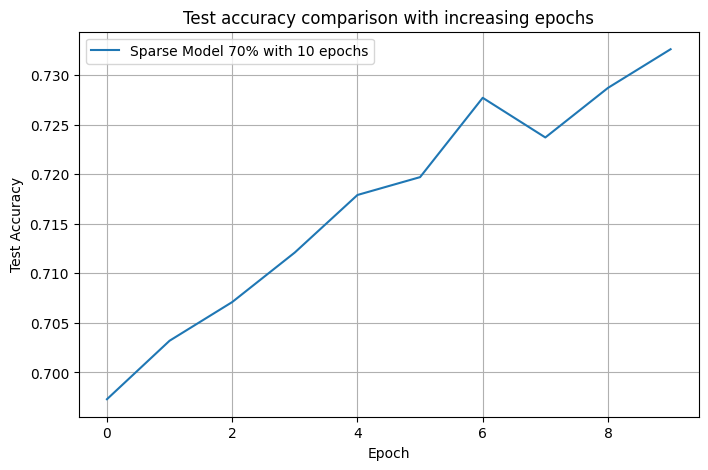

In [41]:
plt.figure(figsize=(8,5))
plt.plot(pruned_test_acc_70_10, label="Sparse Model 70% with 10 epochs")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test accuracy comparison with increasing epochs")
plt.legend()
plt.grid(True)
plt.show()

**Comparison of performance accuracy between different learning rates**

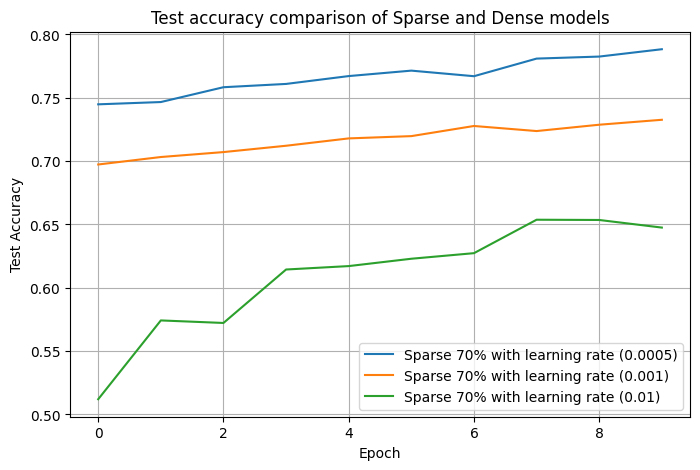

In [40]:
plt.figure(figsize=(8,5))
plt.plot(pruned_test_acc_70_10_lr, label="Sparse 70% with learning rate (0.0005)")
plt.plot(pruned_test_acc_70_10, label="Sparse 70% with learning rate (0.001)")
plt.plot(pruned_test_acc_70_10_lr_1, label="Sparse 70% with learning rate (0.01)")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test accuracy comparison of Sparse and Dense models")
plt.legend()
plt.grid(True)
plt.show()

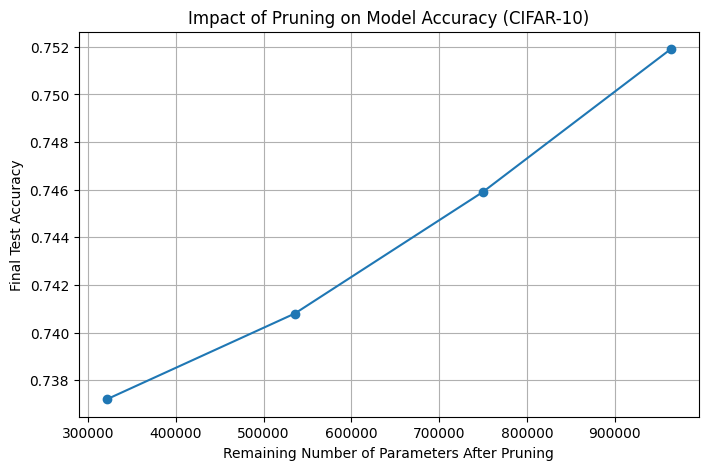

In [ ]:
import matplotlib.pyplot as plt

# Extract values from results
x = [r["remaining_params"] for r in results]   # X-axis
y = [r["test_accuracy"] for r in results]      # Y-axis

# Create plot
plt.figure(figsize=(8, 5))

plt.plot(x, y, marker="o")

# Labels (important for grading)
plt.xlabel("Remaining Number of Parameters After Pruning")
plt.ylabel("Final Test Accuracy")

# Title
plt.title("Impact of Pruning on Model Accuracy (CIFAR-10)")

# Grid for better readability
plt.grid(True)

# Show plot
plt.show()

**Comparision of accuracy between baseline and sparse models**

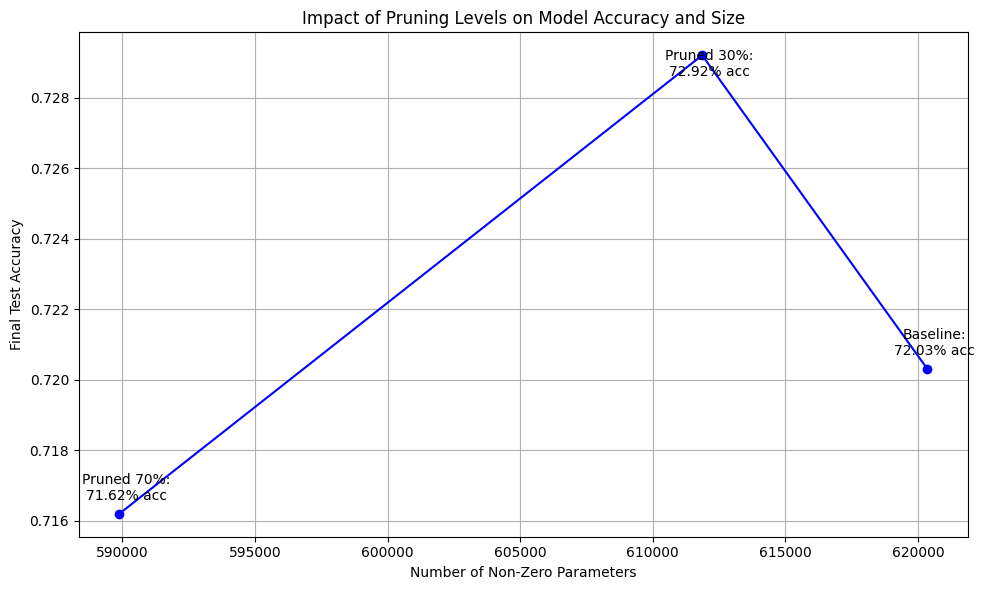

In [42]:
import matplotlib.pyplot as plt

# Data points for the graph
param_counts = [
    dense_non_zero_params,
    sparse_non_zero_params,
    sparse_non_zero_params_70
]

accuracies = [
    baseline_3_test_acc[-1],
    pruned_test_acc[-1],
    pruned_test_acc_70[-1]
]

labels = ['Baseline', 'Pruned 30%', 'Pruned 70%']

# Create plot
plt.figure(figsize=(10, 6))

plt.plot(param_counts, accuracies, marker='o', linestyle='-', color='blue')

# Add labels to each point for clarity, excluding the 'Pruned 70%' label
for i, (param, acc) in enumerate(zip(param_counts, accuracies)):
        plt.annotate(f'{labels[i]}:\n{acc*100:.2f}% acc',
                     (param, acc),
                     textcoords="offset points",
                     xytext=(5,10 if i % 2 == 0 else -15),
                     ha='center')

# Labels (important for grading)
plt.xlabel("Number of Non-Zero Parameters")
plt.ylabel("Final Test Accuracy")

# Title
plt.title("Impact of Pruning Levels on Model Accuracy and Size")

# Grid for better readability
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()

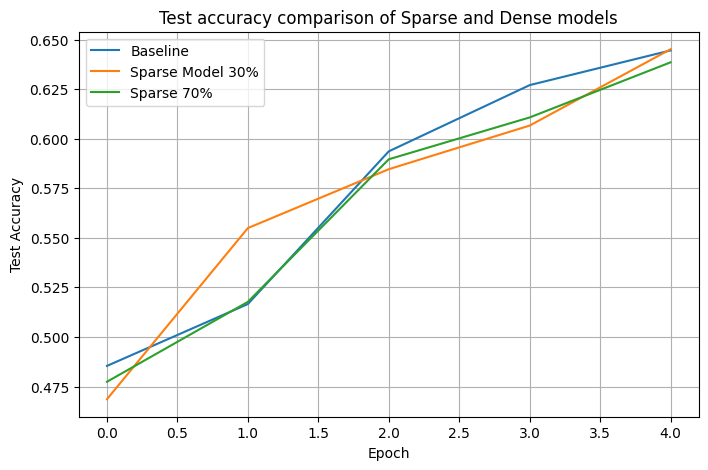

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(baseline_3_test_acc, label="Baseline")
plt.plot(pruned_test_acc, label="Sparse Model 30%")
plt.plot(pruned_test_acc_70, label="Sparse 70%")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test accuracy comparison of Sparse and Dense models")
plt.legend()
plt.grid(True)
plt.show()

**Model Size comparison between sparse and dense models**

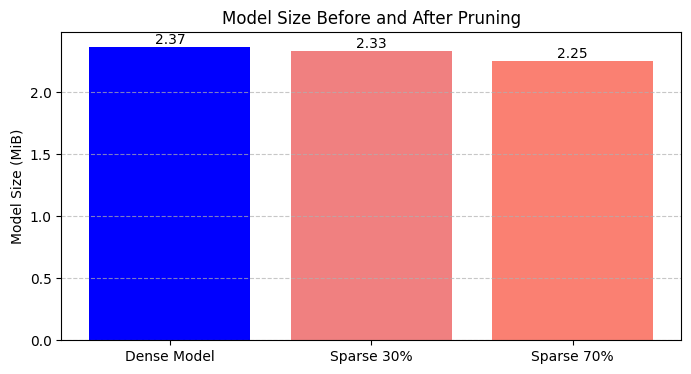

In [43]:
labels_size = ['Dense Model', 'Sparse 30%', 'Sparse 70%']
# Ensure sparse_model_size is on CPU and converted to a Python number for plotting
size_counts = [dense_model_size.cpu().item() / MiB, sparse_model_size.cpu().item() / MiB, sparse_model_size_70.cpu().item() / MiB ]

plt.figure(figsize=(8, 4))
plt.bar(labels_size, size_counts, color=['blue', 'lightcoral', 'salmon'])
plt.ylabel('Model Size (MiB)')
plt.title('Model Size Before and After Pruning')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numerical labels on top of bars
for i, count in enumerate(size_counts):
    plt.text(i, count, f'{count:.2f}', ha='center', va='bottom')

plt.show()

**Parameter size comparison between dense and sparse models**

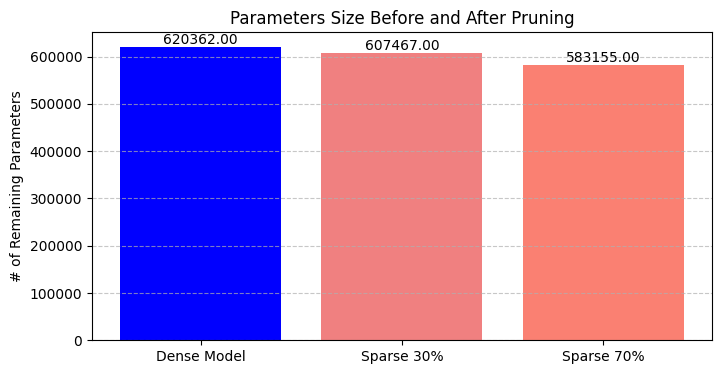

In [ ]:
labels_size = ['Dense Model', 'Sparse 30%', 'Sparse 70%']
# Ensure sparse_model_size is on CPU and converted to a Python number for plotting
size_counts = [dense_non_zero_params, sparse_non_zero_params, sparse_non_zero_params_70 ]

plt.figure(figsize=(8, 4))
plt.bar(labels_size, size_counts, color=['blue', 'lightcoral', 'salmon'])
plt.ylabel('# of Remaining Parameters')
plt.title('Parameters Size Before and After Pruning')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numerical labels on top of bars
for i, count in enumerate(size_counts):
    plt.text(i, count, f'{count:.2f}', ha='center', va='bottom')

plt.show()